**Telecom X — Parte 2: Predicción de Evasión de Clientes**

**Descripción:**
En esta segunda parte del desafío aplicamos modelos de Machine Learning para predecir qué clientes tienen mayor probabilidad de cancelar el servicio (Churn). Utilizamos los datos ya limpios de la Parte 1 y construimos dos modelos predictivos para ayudar a Telecom X a anticiparse a la evasión de clientes.

**Herramientas utilizadas:**
- Python
- Pandas
- Matplotlib
- Scikit-learn

**Nota:** Es importante que antes de hacer codigo subas el archivo  datos_tratados.csv para traer los datos a tratat.
**como?:** En el panel izquierdo haz clic en el ícono de carpeta se llama 'archivos', luego en el ícono de subir archivo (la flecha apuntado arriba), ahi busca el archivo datos_tratados.csv y cargalo.  

In [1]:
#  importaciones
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Cargo los datos tratados de la Parte 1
df = pd.read_csv('datos_tratados.csv')

print("Datos cargados correctamente")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(df.head())

Datos cargados correctamente
Filas: 7032 | Columnas: 21
   customerID  Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO      0  Female              0     Yes        Yes       9   
1  0003-MKNFE      0    Male              0      No         No       9   
2  0004-TLHLJ      1    Male              0      No         No       4   
3  0011-IGKFF      1    Male              1     Yes         No      13   
4  0013-EXCHZ      1  Female              1     Yes         No       3   

  PhoneService MultipleLines InternetService  ... OnlineBackup  \
0          Yes            No             DSL  ...          Yes   
1          Yes           Yes             DSL  ...           No   
2          Yes            No     Fiber optic  ...           No   
3          Yes            No     Fiber optic  ...          Yes   
4          Yes            No     Fiber optic  ...           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No      

# Preparación de datos
En esta sección eliminamos las columnas irrelevantes, aplicamos encoding, verificamos la proporción de Churn y normalizamos los datos.

Se quedaron: 73.4%
Se fueron: 26.6%


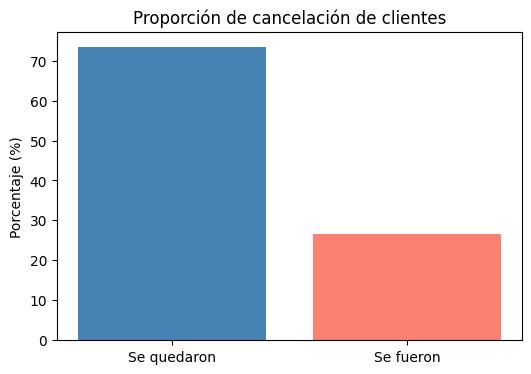

Datos preparados correctamente
Columnas: 31


In [2]:
# ELIMINACIÓN DE COLUMNAS IRRELEVANTES
# Aqui elimino customerID porque es solo un identificador, no ayuda a predecir
df = df.drop(columns=['customerID'])

# ENCODING
# Aqui convierto las columnas de texto a números con get_dummies
df = pd.get_dummies(df, drop_first=True)

# VERIFICACIÓN DE PROPORCIÓN DE CHURN
proporcion = df['Churn'].value_counts(normalize=True) * 100
print(f"Se quedaron: {proporcion[0]:.1f}%")
print(f"Se fueron: {proporcion[1]:.1f}%")

# Visualizo la proporción
plt.figure(figsize=(6, 4))
plt.bar(['Se quedaron', 'Se fueron'], proporcion.values, color=['steelblue', 'salmon'])
plt.title('Proporción de cancelación de clientes')
plt.ylabel('Porcentaje (%)')
plt.show()

# NORMALIZACIÓN
# Aqui se normalizan solo las columnas numéricas continuas
# porque los modelos como Regresión Logística son sensibles a la escala
scaler = StandardScaler()
columnas_normalizar = ['tenure', 'Cargos_Mensuales', 'Cargos_Totales']
df[columnas_normalizar] = scaler.fit_transform(df[columnas_normalizar])

print("Datos preparados correctamente")
print(f"Columnas: {df.shape[1]}")

# Correlación y selección de variables

aqui analizamos qué variables tienen mayor relación con la evasión de clientes.

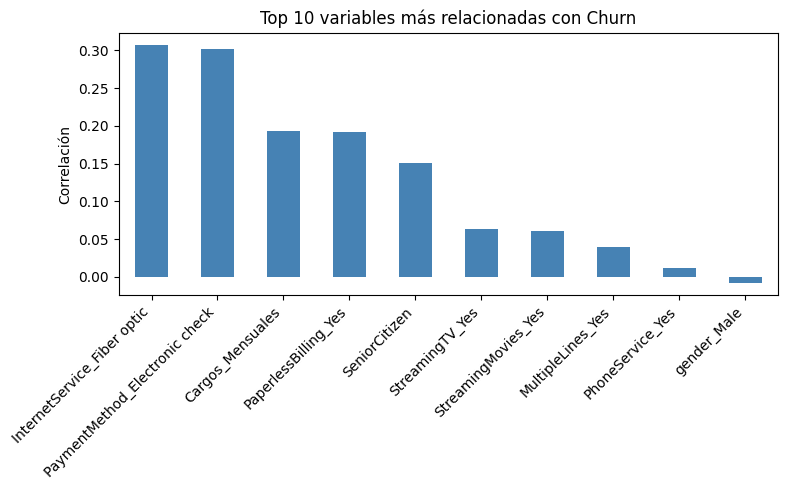

Variables con mayor correlación positiva con Churn:
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
Cargos_Mensuales                  0.192858
PaperlessBilling_Yes              0.191454
SeniorCitizen                     0.150541
Name: Churn, dtype: float64


In [3]:
# CORRELACIÓN Y SELECCIÓN DE VARIABLES
# Aqui voy a visualizar qué variables tienen más relación con Churn
correlacion = df.corr()['Churn'].sort_values(ascending=False)

# Gráfica de las 10 variables más correlacionadas con Churn
plt.figure(figsize=(8, 5))
correlacion[1:11].plot(kind='bar', color='steelblue')
plt.title('Top 10 variables más relacionadas con Churn')
plt.ylabel('Correlación')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Variables con mayor correlación positiva con Churn:")
print(correlacion[1:6])

# Modelado predictivo
Aqui separamos los datos en entrenamiento y prueba, y entrenamos dos modelos diferentes para predecir la evasión.

In [4]:
# SEPARACIÓN DE DATOS
# X son las variables que usa el modelo para predecir
# y es lo que queremos predecir (Churn)
# 80% entrenamiento y 20% prueba
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} filas")
print(f"Datos de prueba: {X_test.shape[0]} filas")

# CREACIÓN DE MODELOS

# Modelo 1: Regresión Logística (Este requiere normalización)
modelo_rl = LogisticRegression(max_iter=1000)
modelo_rl.fit(X_train, y_train)
pred_rl = modelo_rl.predict(X_test)

print("\n=== Regresión Logística ===")
print(f"Exactitud:  {accuracy_score(y_test, pred_rl):.2f}")
print(f"Precisión:  {precision_score(y_test, pred_rl):.2f}")
print(f"Recall:     {recall_score(y_test, pred_rl):.2f}")
print(f"F1-score:   {f1_score(y_test, pred_rl):.2f}")

# Modelo 2: Árbol de Decisión (Este no requiere normalización)
modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt.fit(X_train, y_train)
pred_dt = modelo_dt.predict(X_test)

print("\n=== Árbol de Decisión ===")
print(f"Exactitud:  {accuracy_score(y_test, pred_dt):.2f}")
print(f"Precisión:  {precision_score(y_test, pred_dt):.2f}")
print(f"Recall:     {recall_score(y_test, pred_dt):.2f}")
print(f"F1-score:   {f1_score(y_test, pred_dt):.2f}")

Datos de entrenamiento: 5625 filas
Datos de prueba: 1407 filas

=== Regresión Logística ===
Exactitud:  0.80
Precisión:  0.64
Recall:     0.54
F1-score:   0.59

=== Árbol de Decisión ===
Exactitud:  0.72
Precisión:  0.47
Recall:     0.51
F1-score:   0.49


# Evaluación de los modelos
Aqui vamos a visualizar las matrices de confusión para entender mejor los errores de cada modelo.

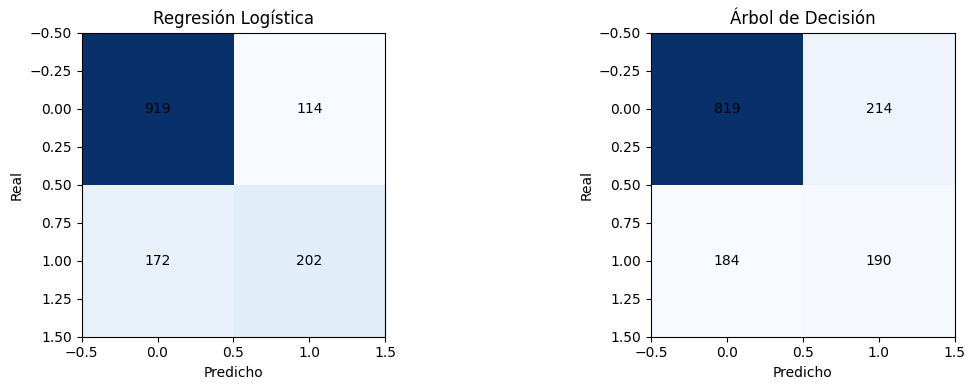

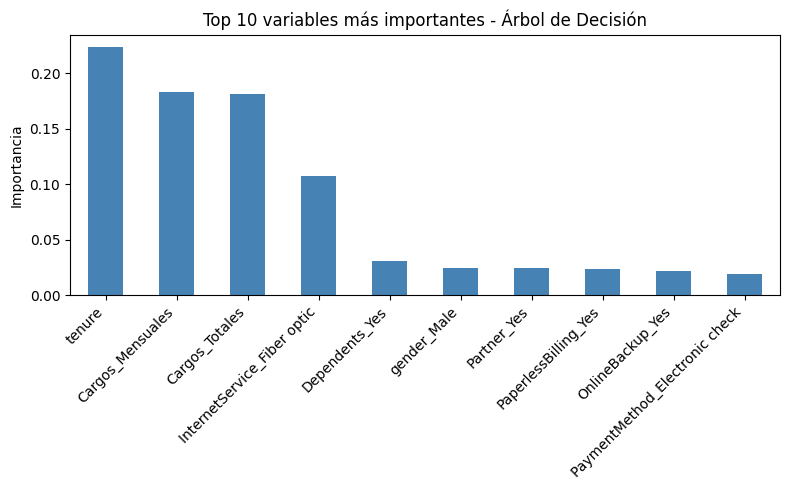


=== CONCLUSIÓN ===
El modelo de Regresión Logística tuvo mejor desempeño con 80% de exactitud.
Las variables más importantes para predecir la evasión son:
- Tiempo como cliente (tenure)
- Tipo de contrato (mes a mes)
- Tipo de internet (fibra óptica)
- Cargos mensuales altos
Se recomienda enfocarse en retener clientes nuevos con contrato mes a mes.


In [7]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_rl = confusion_matrix(y_test, pred_rl)
axes[0].imshow(cm_rl, cmap='Blues')
axes[0].set_title('Regresión Logística')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_rl[i, j], ha='center', va='center', color='black')

cm_dt = confusion_matrix(y_test, pred_dt)
axes[1].imshow(cm_dt, cmap='Blues')
axes[1].set_title('Árbol de Decisión')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm_dt[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

# Importancia de variables
importancia = pd.Series(modelo_dt.feature_importances_, index=X.columns)
importancia = importancia.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importancia.plot(kind='bar', color='steelblue')
plt.title('Top 10 variables más importantes - Árbol de Decisión')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# CONCLUSIÓN
print("\n=== CONCLUSIÓN ===")
print("El modelo de Regresión Logística tuvo mejor desempeño con 80% de exactitud.")
print("Las variables más importantes para predecir la evasión son:")
print("- Tiempo como cliente (tenure)")
print("- Tipo de contrato (mes a mes)")
print("- Tipo de internet (fibra óptica)")
print("- Cargos mensuales altos")
print("Se recomienda enfocarse en retener clientes nuevos con contrato mes a mes.")

**Conclusión:**

En base a los datos concluimos que la Regresión Logística fue el mejor modelo.

# Conclusiones

La Regresión Logística fue el modelo con mejor desempeño, alcanzando un 80% de exactitud. Esto significa que de cada 100 clientes el modelo predijo correctamente 80 casos.

Sin embargo el Recall de 0.54 indica que el modelo solo detectó el 54% de los clientes que realmente se fueron, es decir, se perdió casi la mitad de los casos de evasión. Esto es un punto importante a mejorar en futuras versiones del modelo.

Las variables que más influyen en la evasión de clientes son:

- **Tiempo como cliente (tenure)** — los clientes nuevos se van más
- **Tipo de contrato** — los contratos mes a mes tienen mayor riesgo de cancelación
- **Tipo de internet** — los clientes con fibra óptica se van más
- **Cargos mensuales altos** — a mayor precio, mayor probabilidad de irse

Otro punto importante es que el modelo tiene dificultad para detectar a los clientes que se van — solo identificó el 54% de ellos. Para una empresa como Telecom X esto es crítico, porque cada cliente que el modelo no detecta es un cliente que se pierde sin que la empresa pueda hacer nada. Por eso se recomienda mejorar el modelo en el futuro con más datos o técnicas más avanzadas.

# Recomendación estratégica

Con base en los resultados del análisis se recomienda a Telecom X:

1. **Enfocarse en clientes nuevos**: la mayoría de las cancelaciones ocurren en los primeros meses. Implementar un programa de bienvenida o descuentos para los primeros 6 meses podría reducir la evasión.

2. **Revisar los precios de fibra óptica**: los clientes con este servicio se van más, posiblemente porque sienten que el precio no justifica el servicio. Se recomienda evaluar si el precio es competitivo en el mercado.

3. **Incentivar contratos anuales**: ofrecer beneficios a los clientes que pasen de contrato mes a mes a contrato anual, ya que estos tienen mucho menor probabilidad de cancelar.

4. **Revisar el método de pago electrónico**: los clientes que pagan con cheque electrónico se van más. Podría investigarse si hay problemas con este método de pago.